# MIT-BIH ECG Preprocessing Pipeline – Overview

**Workflow:**

Raw ECG Records (48 patients)  
Bandpass Filtering (0.5–40 Hz)  
R-Peak Detection  
Heartbeat Segmentation (Fixed Window)  
Z-score Normalization  
Label Mapping → AAMI Classes 
Save as `.npz` (beats + labels)



In [1]:
import sys
import os

script_path = os.path.abspath("../Scripts")
sys.path.append(script_path)

from preprocess_pipeline import ECGPreprocessor
import numpy as np
import matplotlib.pyplot as plt

In [3]:
DATA_DIR = "../Data/Raw"          # folder containing 100.dat, 100.hea, 100.atr files
SAVE_DIR = "../Data/Processed"    # folder where processed .npz files will be stored

os.makedirs(SAVE_DIR, exist_ok=True)

print("Raw Data Folder:", DATA_DIR)
print("Output Folder:", SAVE_DIR)


Raw Data Folder: ../Data/Raw
Output Folder: ../Data/Processed


In [15]:
records = [
    "101", "102", "103", "104",
    "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115",
    "116", "117", "118", "119", "121",
    "122", "123", "124", "200", "201",
    "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214",
    "215", "217", "219", "220", "221",
    "222", "223", "228", "230", "231",
    "232", "233", "234"
]

len(records)


47

In [7]:
pre = ECGPreprocessor(
    data_path=DATA_DIR,
    save_path=SAVE_DIR,
    fs=360
)


### Testing Pipeline on sample data

In [10]:
test_record = "100"
beats, labels = pre.preprocess_record(test_record)

print("Beats shape:", beats.shape)
print("Number of labels:", len(labels))
print("Unique labels:", set(labels))



Processing Record: 100
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Saved preprocessed file: ../Data/Processed\100.npz
Beats shape: (2271, 250)
Number of labels: 2270
Unique labels: {'S', 'V', 'N'}


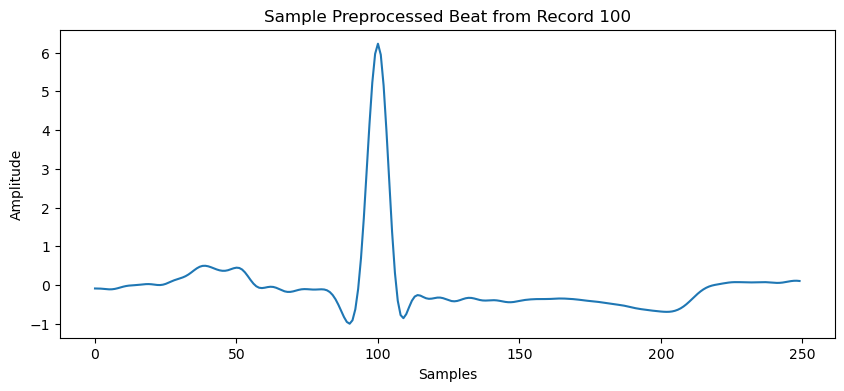

In [12]:
plt.figure(figsize=(10,4))
plt.plot(beats[0])
plt.title(f"Sample Preprocessed Beat from Record {test_record}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


### Preprocessing all records

In [17]:
print("Starting batch preprocessing of all MIT-BIH records...\n")
pre.preprocess_all_records(records)
print("\nBatch preprocessing completed!")


Starting batch preprocessing of all MIT-BIH records...


Processing Record: 101
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Saved preprocessed file: ../Data/Processed\101.npz

Processing Record: 102
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Saved preprocessed file: ../Data/Processed\102.npz

Processing Record: 103
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Saved preprocessed file: ../Data/Processed\103.npz

Processing Record: 104
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Saved preprocessed file: ../Data/Processed\104.npz

Processing Record: 

In [33]:
saved_files = os.listdir(SAVE_DIR)
saved_files[:10], len(saved_files)


(['.ipynb_checkpoints',
  '100.npz',
  '101.npz',
  '102.npz',
  '103.npz',
  '104.npz',
  '105.npz',
  '106.npz',
  '107.npz',
  '109.npz'],
 50)

In [27]:
records = [
    "101", "102", "103", "104",
    "105", "106", "107", "109",
    "111", "112", "113", "114", "115",
    "116", "117", "118", "119", "121",
    "122", "123", "124", "200", "201",
    "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214",
    "215", "217", "219", "220", "221",
    "222", "223", "228", "230", "231",
    "232", "233", "234"
]

# Removing 108 record as it has errored data

### Single Preprocessed file

In [30]:
data = np.load(os.path.join(SAVE_DIR, "100.npz"), allow_pickle=True)
beats_100 = data["beats"]
labels_100 = data["labels"]

print("Beats:", beats_100.shape)
print("Labels:", len(labels_100))
print("Unique Labels:", set(labels_100))


Beats: (2271, 250)
Labels: 2270
Unique Labels: {'S', 'V', 'N'}


### Global Class Distribution Across All Records

In [35]:
from collections import Counter

all_labels = []

for rec in records:
    f = np.load(os.path.join(SAVE_DIR, f"{rec}.npz"), allow_pickle=True)
    all_labels.extend(f["labels"])

dist = Counter(all_labels)
dist


Counter({'N': 84091, 'V': 6792, 'S': 2588, 'F': 780})

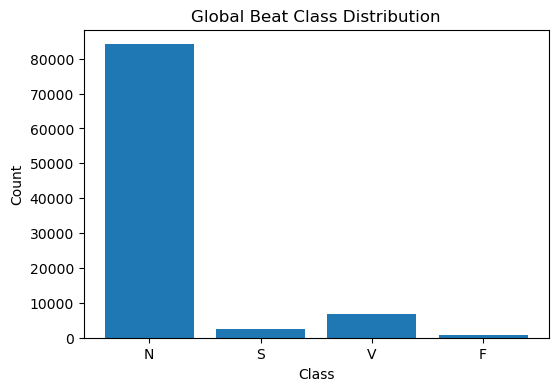

In [37]:
plt.figure(figsize=(6,4))
plt.bar(list(dist.keys()), list(dist.values()))
plt.title("Global Beat Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [39]:
summary = {
    "total_beats": len(all_labels),
    "class_distribution": dist
}

summary


{'total_beats': 94251,
 'class_distribution': Counter({'N': 84091, 'V': 6792, 'S': 2588, 'F': 780})}